# k-Nearest Neighbour Classification #

#### Imports ####

In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.inspection import permutation_importance
import os
import seaborn as sns
import matplotlib.pyplot as plt

#### Load Cleaned Dataset ####

In [5]:
script_dir = os.getcwd()
rel_path = "intermediate"

dataset = pd.read_csv(os.path.join(script_dir, rel_path, "CLEAN_data_injection_moulding.csv"))

#### Feature Selection ####

Essential features include cushion volume (ACPx), injection time (ZSx), two temperature measures (H16x and H10x).

Additionally chosen features include dosing time (ZDx), energy consumption (GEx) and cycle time (ZUs). However these might show multicollinearity, so they need to be monitored

In [10]:
features = ['ZSx [s]', 'ACPx [cm³]', 'ZDx [s]', 'ZUs [s]', 'ZEx [s]', 'GEx [kWh]', 'H16x [°C]', 'H10x [°C]']

X = dataset[features]
y = dataset['ASZ [Sch]']

#### Splitting and Scaling Data ####

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#### Train kNN ####

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [6]:
%store knn

Stored 'knn' (KNeighborsClassifier)


#### Evaluate Model ####

Stored 'knn_base_pred' (ndarray)
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       933
           1       0.90      0.97      0.94        38

    accuracy                           0.99       971
   macro avg       0.95      0.98      0.97       971
weighted avg       1.00      0.99      0.99       971



#### Plot Confusion Matrix ####

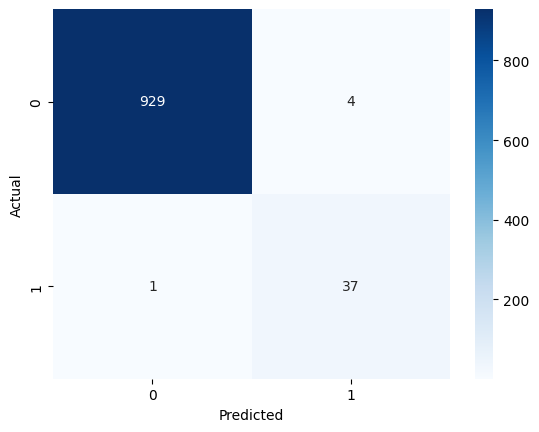

In [15]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

True Negatives = 929
True Positives = 37
False Negatives = 1
False Positives = 4

#### Double-checking if one feature is carrying the entire model ####
We shuffle one column at a time and see if the model's performance drops.

ZUs [s]: 0.069
ZSx [s]: 0.001
ZEx [s]: 0.000
GEx [kWh]: 0.000
H16x [°C]: -0.000
ZDx [s]: -0.000
H10x [°C]: -0.001
ACPx [cm³]: -0.001


We see that demolding time dominates the model, to the point where the other features play no role. Hence, we remove ZUs and rerun.

              precision    recall  f1-score   support

           0       0.98      1.00      0.99       933
           1       0.91      0.53      0.67        38

    accuracy                           0.98       971
   macro avg       0.95      0.76      0.83       971
weighted avg       0.98      0.98      0.98       971



By removing cycle time, our recall for scrap dropped from 97% to 53%. This means that defective parts are indistinguishable from good ones uing only the remaining sensors.

We try rerunning but now making the model look for only 3 neighbours instead of 5.

In [11]:
features = ['ZSx [s]', 'ACPx [cm³]', 'ZDx [s]', 'ZEx [s]', 'GEx [kWh]', 'H16x [°C]', 'H10x [°C]']

X2 = dataset[features]

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X2, y, test_size=0.2, random_state=42)
scaler_2 = StandardScaler()
X_train_2 = scaler_2.fit_transform(X_train_2)
X_test_2 = scaler_2.transform(X_test_2)

knn_2 = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn_2.fit(X_train_2, y_train_2)
y_pred_2 = knn_2.predict(X_test_2)

print(classification_report(y_test_2, y_pred_2))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       933
           1       0.79      0.50      0.61        38

    accuracy                           0.98       971
   macro avg       0.89      0.75      0.80       971
weighted avg       0.97      0.98      0.97       971



Before SMOTE: 125 scrap samples
After SMOTE: 3758 scrap samples
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       933
           1       0.54      0.76      0.63        38

    accuracy                           0.96       971
   macro avg       0.76      0.87      0.81       971
weighted avg       0.97      0.96      0.97       971



In [25]:
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# 1. Initialize SMOTE
# We only apply this to the TRAINING data to avoid data leakage
sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_2, y_train_2)

print(f'Before SMOTE: {sum(y_train_2 == 1)} scrap samples')
print(f'After SMOTE: {sum(y_train_res == 1)} scrap samples')

# 2. Re-train the kNN on the balanced dataset
# I recommend setting weights='distance' so closer points have more influence
knn_smote = KNeighborsClassifier(n_neighbors=3, weights='distance')
knn_smote.fit(X_train_res, y_train_res)

# 3. Evaluate on the original (un-smoted) test set
y_pred_smote = knn_smote.predict(X_test_2)

print(classification_report(y_test_2, y_pred_smote))

Before SMOTE: 125 scrap samples
After SMOTE: 3758 scrap samples
              precision    recall  f1-score   support

           0       0.99      0.97      0.98       933
           1       0.54      0.76      0.63        38

    accuracy                           0.96       971
   macro avg       0.76      0.87      0.81       971
weighted avg       0.97      0.96      0.97       971

